# Análisis Detallado de Sensibilidad Emocional — Llama3, Mistral, Phi-3 y Nemotron3 (50 Iteraciones)
En este notebook se analizan los resultados de los experimentos realizados con 50 iteraciones para los modelos **Llama 3**, **Mistral**, **Phi-3** y **Nemotron3 33B**. El objetivo es evaluar la consistencia de los modelos y el impacto de diferentes emociones en sus respuestas.

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from textblob import TextBlob
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jonat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jonat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Carga y Unificación de Datasets
Cargamos únicamente los archivos CSV de **llama3**, **mistral**, **phi3** y **nemotron3** de la carpeta `dataset_experiemento_50iter/` y los combinamos en un solo DataFrame.

In [2]:
ruta_datasets = "../dataset_experiemento_50iter/"

# Solo cargamos los modelos de interés
modelos_objetivo = ["llama3", "mistral", "phi3", "nemotron3_33b"]

dataframes = []
for modelo in modelos_objetivo:
    patron = os.path.join(ruta_datasets, f"sensibilidad_{modelo}_50iter.csv")
    archivos = glob.glob(patron)
    if not archivos:
        print(f"[ADVERTENCIA] No se encontró archivo para el modelo: {modelo}")
        continue
    for archivo in archivos:
        nombre_modelo = os.path.basename(archivo).replace("sensibilidad_", "").replace("_50iter.csv", "")
        df_temp = pd.read_csv(archivo)
        df_temp["model"] = nombre_modelo
        dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)

# Renombrar columnas para consistencia si es necesario
df.rename(columns={
    "emocion": "emotion",
    "respuesta": "response",
    "longitud": "length"
}, inplace=True)

print(f"Total de registros cargados: {len(df)}")
print(f"Modelos cargados: {df['model'].unique().tolist()}")
df.head()

Total de registros cargados: 1200
Modelos cargados: ['llama3', 'mistral', 'phi3', 'nemotron3_33b']


,modelo,emotion,iteracion,prompt,response,length,diversidad,model
0,llama3,neutral,1,Explícame cómo funciona una red neuronal.,"Las redes neuronales (o deep learning, en ingl...",134,0.768657,llama3
1,llama3,neutral,2,Explícame cómo funciona una red neuronal.,¡Claro! Las redes neuronales (RN) son modelos ...,122,0.721311,llama3
2,llama3,neutral,3,Explícame cómo funciona una red neuronal.,La magia de las redes neuronales!\n\nUna red n...,121,0.776860,llama3
3,llama3,neutral,4,Explícame cómo funciona una red neuronal.,¡Claro! Las redes neuronales (RN) son modelos ...,125,0.736000,llama3
4,llama3,neutral,5,Explícame cómo funciona una red neuronal.,Excelente elección! Las redes neuronales (RN) ...,114,0.807018,llama3


## 2. Feature Engineering
Calculamos métricas adicionales para profundizar en el análisis lingüístico y sentimental.

In [3]:
def lexical_diversity(text):
    words = str(text).split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

def sentence_length(text):
    sentences = nltk.sent_tokenize(str(text))
    if len(sentences) == 0:
        return 0
    return np.mean([len(s.split()) for s in sentences])

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

def pronoun_usage(text):
    pronouns = ["yo", "tú", "te", "usted", "nosotros", "mí", "conmigo"]
    words = str(text).lower().split()
    return sum(1 for w in words if w in pronouns)

df["lexical_diversity"] = df["response"].apply(lexical_diversity)
df["sentence_length"] = df["response"].apply(sentence_length)
df["sentiment"] = df["response"].apply(get_sentiment)
df["subjectivity"] = df["response"].apply(get_subjectivity)
df["pronouns"] = df["response"].apply(pronoun_usage)

df.head()

,modelo,emotion,iteracion,prompt,response,length,diversidad,model,lexical_diversity,sentence_length,sentiment,subjectivity,pronouns
0,llama3,neutral,1,Explícame cómo funciona una red neuronal.,"Las redes neuronales (o deep learning, en ingl...",134,0.768657,llama3,0.768657,19.142857,-0.071429,0.308163,0
1,llama3,neutral,2,Explícame cómo funciona una red neuronal.,¡Claro! Las redes neuronales (RN) son modelos ...,122,0.721311,llama3,0.721311,11.181818,-0.120000,0.200000,0
2,llama3,neutral,3,Explícame cómo funciona una red neuronal.,La magia de las redes neuronales!\n\nUna red n...,121,0.776860,llama3,0.776860,12.100000,-0.200000,0.333333,1
3,llama3,neutral,4,Explícame cómo funciona una red neuronal.,¡Claro! Las redes neuronales (RN) son modelos ...,125,0.736000,llama3,0.736000,13.888889,0.000000,0.000000,1
4,llama3,neutral,5,Explícame cómo funciona una red neuronal.,Excelente elección! Las redes neuronales (RN) ...,114,0.807018,llama3,0.807018,10.363636,0.125000,0.500000,1


## 3. Resumen Estadístico
Agrupamos por modelo y emoción para comparar los promedios.

In [4]:
summary = df.groupby(["model", "emotion"]).agg({
    "length": ["mean", "std"],
    "sentiment": ["mean", "std"],
    "lexical_diversity": "mean",
    "sentence_length": "mean",
    "subjectivity": "mean",
    "pronouns": "mean"
}).reset_index()

summary

model      emotion  length            sentiment            \
                                  mean        std      mean       std   
0          llama3     ansiedad  120.00   4.580348 -0.061759  0.081351   
1          llama3     cortesia  120.08   5.378870 -0.059498  0.070467   
2          llama3        enojo  121.14   6.458691 -0.085606  0.088872   
3          llama3  frustracion  122.36   4.364794 -0.042768  0.077739   
4          llama3      neutral  121.38   5.667271 -0.050540  0.085553   
5          llama3     urgencia  119.98  16.935038 -0.056606  0.081780   
6         mistral     ansiedad  109.22   4.047120 -0.174393  0.068976   
7         mistral     cortesia  109.90   4.210046 -0.121652  0.090249   
8         mistral        enojo  109.78   4.067241 -0.169474  0.080369   
9         mistral  frustracion  109.62   4.270879 -0.120481  0.087670   
10        mistral      neutral  110.30   4.643407 -0.137508  0.075529   
11        mistral     urgencia  111.08   4.681008 -0.167387  0.090966   
12  nemotron3_33b     ansiedad   80.40  11.250397 -0.010883  0.064828   
13  nemotron3_33b     cortesia   67.86  14.396726 -0.121443  0.133878   
14  nemotron3_33b        enojo   63.96  26.982958 -0.057783  0.095767   
15  nemotron3_33b  frustracion   74.16  24.301978 -0.016609  0.079492   
16  nemotron3_33b      neutral   72.90  28.583747  0.011452  0.073340   
17  nemotron3_33b     urgencia   54.66  19.538147 -0.017528  0.054235   
18           phi3     ansiedad  109.24   5.978055 -0.066511  0.110626   
19           phi3     cortesia  111.70   5.273151 -0.060157  0.103026   
20           phi3        enojo  112.38   5.098579 -0.044945  0.113203   
21           phi3  frustracion  110.64   5.259627 -0.059375  0.133965   
22           phi3      neutral  113.52   5.817777 -0.063314  0.116699   
23           phi3     urgencia  110.78   5.800387 -0.031061  0.115631   

   lexical_diversity sentence_length subjectivity pronouns  
                mean            mean         mean     mean  
0           0.777361       12.170190     0.162675     0.96  
1           0.754020       13.111486     0.184732     0.84  
2           0.756786       12.265445     0.206016     0.58  
3           0.778752       12.845331     0.154135     0.84  
4           0.753395       13.696135     0.175719     0.56  
5           0.752210       11.905157     0.181718     0.42  
6           0.718713       16.848016     0.351084     0.24  
7           0.717591       15.830354     0.277528     0.02  
8           0.730001       16.883675     0.313474     0.10  
9           0.722611       15.162270     0.233267     0.32  
10          0.716160       18.453976     0.259619     0.14  
11          0.713567       20.057508     0.315001     0.10  
12          0.814449       12.337079     0.141038     0.62  
13          0.844768       12.117286     0.379967     1.00  
14          0.856009       11.095508     0.262310     0.28  
15          0.850989       10.895198     0.152533     0.20  
16          0.843715       12.543524     0.344929     0.12  
17          0.865754        9.603678     0.062222     0.00  
18          0.815297       20.826548     0.207768     0.34  
19          0.787357       19.932444     0.198157     0.06  
20          0.797528       22.751024     0.176553     0.10  
21          0.819292       21.095095     0.221532     0.32  
22          0.792998       22.381071     0.179415     0.08  
23          0.802806       22.748762     0.172206     0.02

## 4. Variabilidad por Modelo
Medimos qué tan consistentes son los modelos en la longitud de sus respuestas.

In [5]:
variability = df.groupby("model")["length"].std()
print("Desviación estándar de la longitud por modelo:")
print(variability)

Desviación estándar de la longitud por modelo:
model
llama3            8.437382
mistral           4.331157
nemotron3_33b    23.126739
phi3              5.668795
Name: length, dtype: float64


## 5. Análisis de Varianza (ANOVA)
Evaluamos si las diferencias observadas entre emociones son estadísticamente significativas.

In [6]:
def anova_effect(df, variable, model_name):
    subset = df[df["model"] == model_name]
    groups = [subset[subset["emotion"] == e][variable] for e in subset["emotion"].unique()]
    
    if len(groups) < 2:
        return np.nan, np.nan, np.nan
        
    f_stat, p_val = f_oneway(*groups)
    
    grand_mean = subset[variable].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((subset[variable] - grand_mean)**2)
    eta_sq = ss_between / ss_total if ss_total != 0 else 0
    
    return f_stat, p_val, eta_sq

for model in df["model"].unique():
    f, p, eta = anova_effect(df, "length", model)
    print(f"Modelo: {model} -> F={f:.3f}, p={p:.5f}, eta²={eta:.3f}")

Modelo: llama3 -> F=0.658, p=0.65542, eta²=0.011
Modelo: mistral -> F=1.103, p=0.35875, eta²=0.018
Modelo: phi3 -> F=3.628, p=0.00336, eta²=0.058
Modelo: nemotron3_33b -> F=8.504, p=0.00000, eta²=0.126


## 6. Visualizaciones

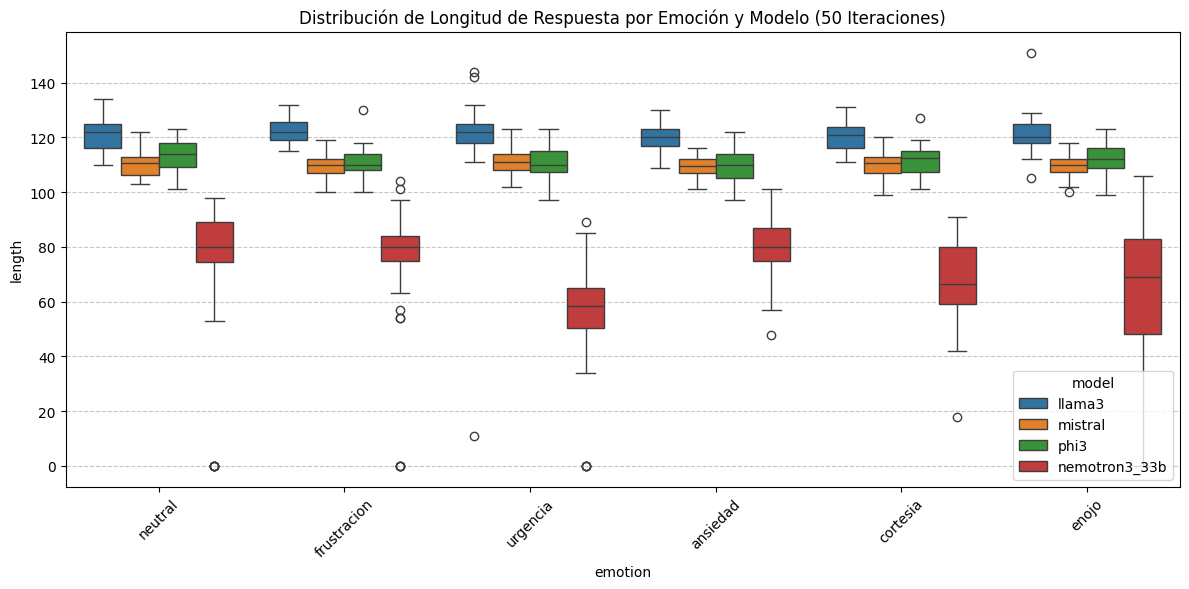

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="emotion", y="length", hue="model")
plt.title("Distribución de Longitud de Respuesta por Emoción y Modelo (50 Iteraciones)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

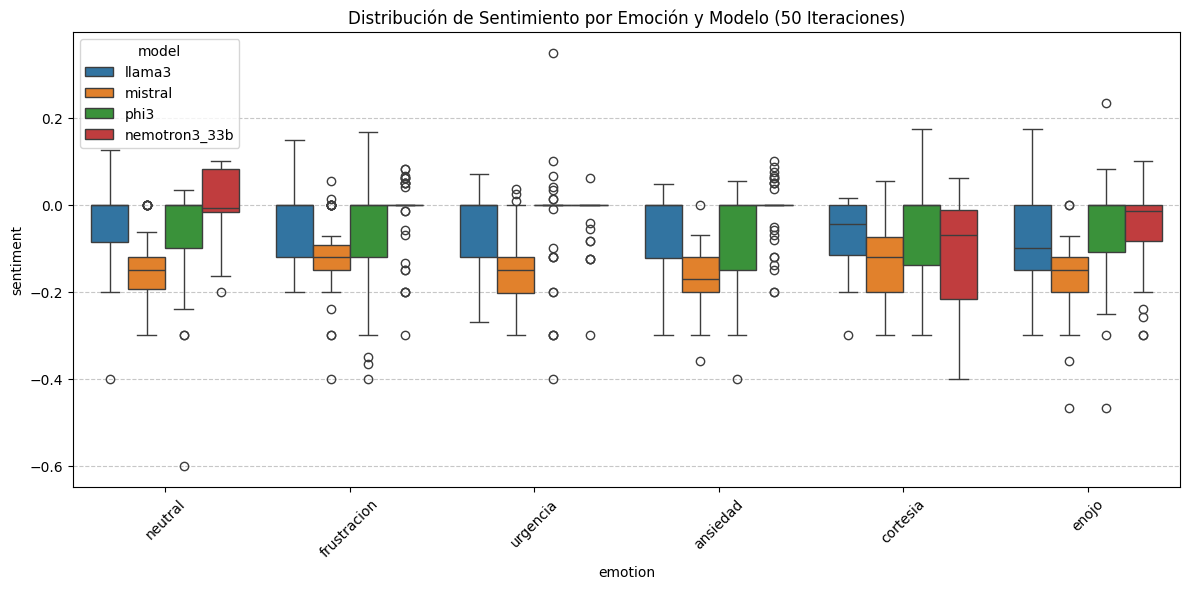

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="emotion", y="sentiment", hue="model")
plt.title("Distribución de Sentimiento por Emoción y Modelo (50 Iteraciones)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

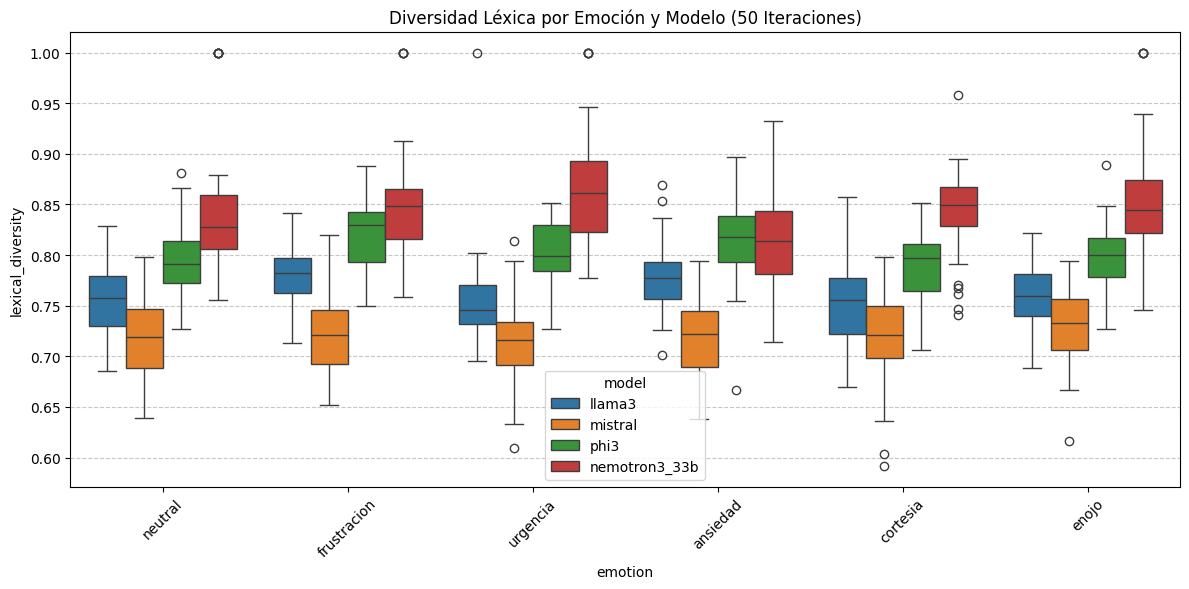

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="emotion", y="lexical_diversity", hue="model")
plt.title("Diversidad Léxica por Emoción y Modelo (50 Iteraciones)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

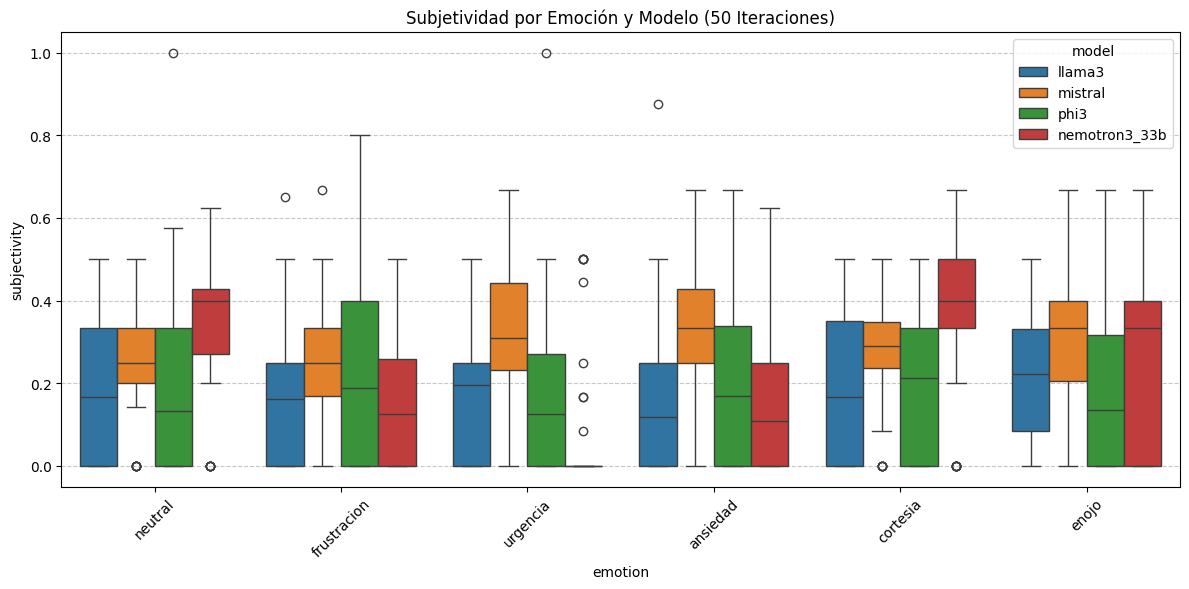

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="emotion", y="subjectivity", hue="model")
plt.title("Subjetividad por Emoción y Modelo (50 Iteraciones)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

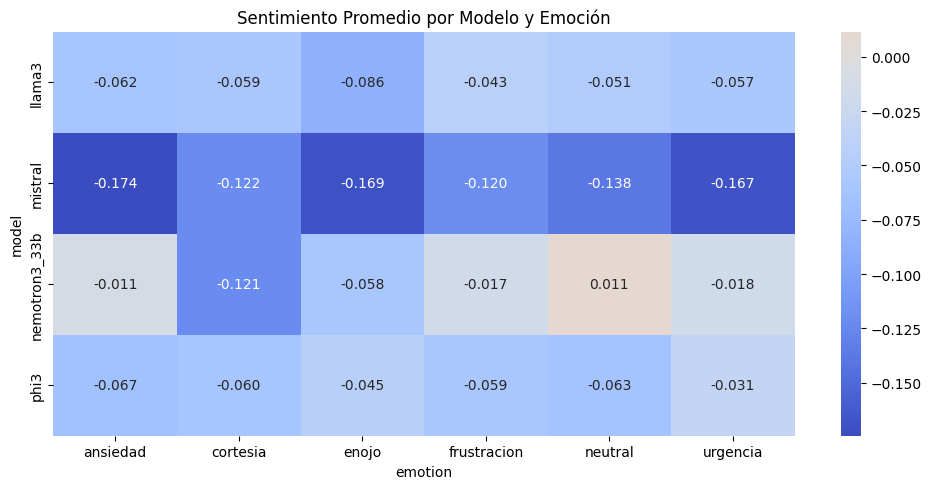

In [11]:
pivot_sentiment = df.groupby(["model", "emotion"])["sentiment"].mean().unstack()
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_sentiment, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Sentimiento Promedio por Modelo y Emoción")
plt.tight_layout()
plt.show()

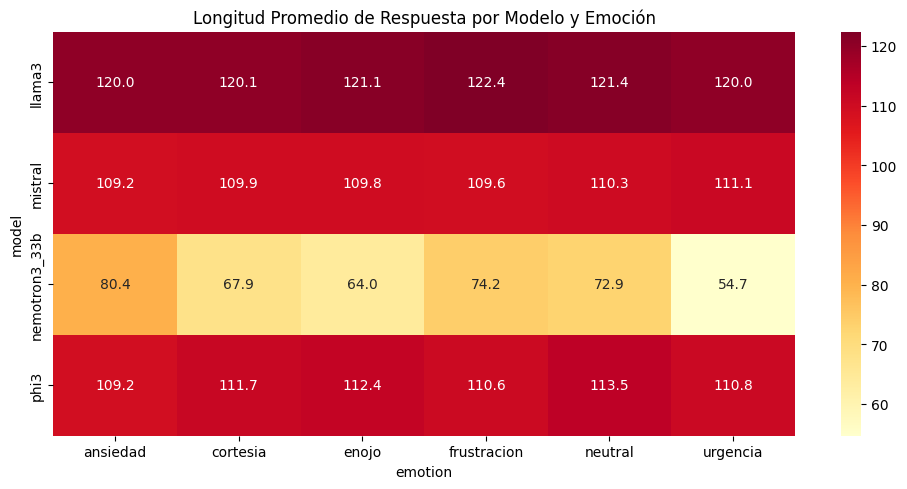

In [12]:
pivot_length = df.groupby(["model", "emotion"])["length"].mean().unstack()
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_length, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Longitud Promedio de Respuesta por Modelo y Emoción")
plt.tight_layout()
plt.show()